Data Understanding and Inspection

--- DATASET OVERVIEW ---
Shape: (5000, 13)
Missing Values: 0

--- TARGET DISTRIBUTION (Leakage_Flag) ---
              Count  Percentage (%)
Leakage_Flag                       
0              4677           93.54
1               323            6.46

--- SENSOR DESCRIPTIVE STATISTICS ---


,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,60.056019,79.851892,100.052765,3.008258,1994.494314,5488.247800
std,9.964798,15.156556,4.993849,0.501668,295.012393,2611.426293
min,27.587327,21.163996,83.122104,1.071812,903.474045,1000.000000
25%,53.420950,69.701256,96.695568,2.667660,1789.471968,3197.500000
50%,60.134656,79.738242,100.049587,3.009630,1997.594952,5489.000000
75%,66.660106,90.158571,103.377671,3.353307,2195.181932,7748.500000
max,99.262377,132.935828,117.144552,5.239542,3083.405019,9998.000000



--- SPATIAL DATA UNIQUE COUNTS ---
Zone: 5 unique values
Block: 5 unique values
Pipe: 5 unique values
Location_Code: 125 unique values
Latitude: 5000 unique values
Longitude: 5000 unique values


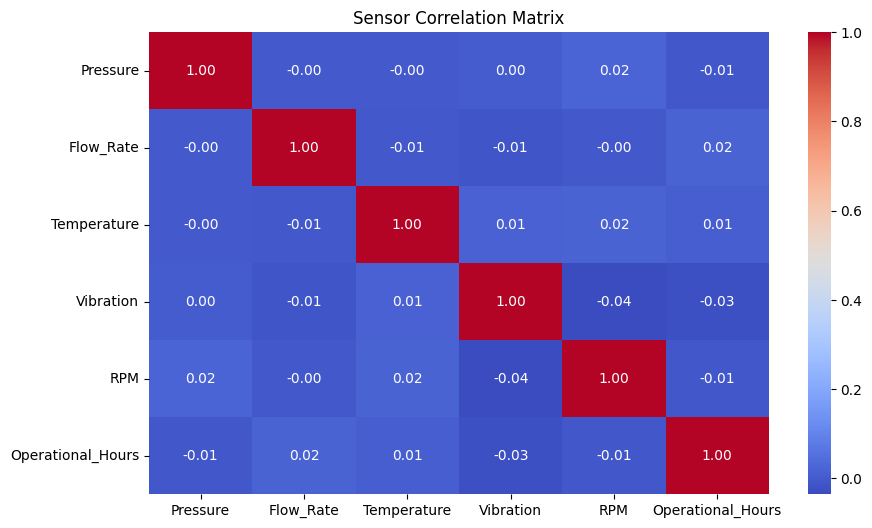

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# Assuming the file is uploaded to the root directory in Colab
file_path = 'location_aware_gis_leakage_dataset.csv'
df = pd.read_csv(file_path)

# 1. Basic Dimensions and Missing Values
print("--- DATASET OVERVIEW ---")
print(f"Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")

# 2. Target Distribution (Detection Model)
print("\n--- TARGET DISTRIBUTION (Leakage_Flag) ---")
leak_counts = df['Leakage_Flag'].value_counts()
leak_percent = df['Leakage_Flag'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': leak_counts, 'Percentage (%)': leak_percent}))

# 3. Sensor Statistics
sensor_cols = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours']
print("\n--- SENSOR DESCRIPTIVE STATISTICS ---")
display(df[sensor_cols].describe())

# 4. Spatial Feature Inventory (For Model 2 Preparation)
spatial_cols = ['Zone', 'Block', 'Pipe', 'Location_Code', 'Latitude', 'Longitude']
print("\n--- SPATIAL DATA UNIQUE COUNTS ---")
for col in spatial_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")

# 5. Correlation Check (Sensor Only)
plt.figure(figsize=(10, 6))
sns.heatmap(df[sensor_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensor Correlation Matrix")
plt.show()

Data Cleaning & Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Isolate target for Model 1 (Detection)
y_detection = df['Leakage_Flag']

# 2. Isolate target for Model 2 (Localization)
# We will encode 'Zone' into numbers 0-4
le = LabelEncoder()
y_localization = le.fit_transform(df['Zone'])

# 3. Define Model 1 Features (Sensors ONLY - No IDs, No GPS)
# This is the 'Location-Agnostic' feature set
sensor_features = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours']
X_detection = df[sensor_features].copy()

# 4. Define Model 2 Features (Sensors + Spatial)
spatial_features = ['Latitude', 'Longitude']
X_localization = df[sensor_features + spatial_features].copy()

print("--- PREPROCESSING SUMMARY ---")
print(f"Detection Model (M1) Feature Names: {list(X_detection.columns)}")
print(f"Localization Model (M2) Feature Names: {list(X_localization.columns)}")
print(f"Zone Classes Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Quick Check for Data Leakage
if any(col in X_detection.columns for col in ['Latitude', 'Longitude', 'Zone', 'Location_Code']):
    print("\nCRITICAL ERROR: Spatial data leaked into Model 1 features!")
else:
    print("\nSUCCESS: Model 1 is location-agnostic.")

--- PREPROCESSING SUMMARY ---
Detection Model (M1) Feature Names: ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours']
Localization Model (M2) Feature Names: ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours', 'Latitude', 'Longitude']
Zone Classes Mapping: {'Zone_1': 0, 'Zone_2': 1, 'Zone_3': 2, 'Zone_4': 3, 'Zone_5': 4}

SUCCESS: Model 1 is location-agnostic.


Feature Engineering

In [ ]:
# We apply engineering to both the detection and localization feature sets
def apply_feature_engineering(df_input):
    df_eng = df_input.copy()

    # 1. Physical Relationship: Pressure/Flow Ratio
    # We add a tiny epsilon (1e-6) to prevent division by zero errors
    df_eng['Pressure_Flow_Ratio'] = df_eng['Pressure'] / (df_eng['Flow_Rate'] + 1e-6)

    # 2. Mechanical Stress: Vibration * RPM
    df_eng['Stress_Index'] = df_eng['Vibration'] * df_eng['RPM']

    # 3. Accumulated Wear: Operational_Hours * RPM
    df_eng['Usage_Intensity'] = df_eng['Operational_Hours'] * df_eng['RPM']

    return df_eng

# Apply the function to our isolated feature sets
X_detection_eng = apply_feature_engineering(X_detection)
X_localization_eng = apply_feature_engineering(X_localization)

# Update our feature name lists to include the new engineered columns
new_features = ['Pressure_Flow_Ratio', 'Stress_Index', 'Usage_Intensity']
sensor_features_extended = sensor_features + new_features

print("--- FEATURE ENGINEERING COMPLETE ---")
print(f"New Features Added: {new_features}")
print(f"Total Features for Model 1: {X_detection_eng.shape[1]}")
print(f"Total Features for Model 2: {X_localization_eng.shape[1]}")

# Display a sample of the new features
display(X_detection_eng[new_features].head())

--- FEATURE ENGINEERING COMPLETE ---
New Features Added: ['Pressure_Flow_Ratio', 'Stress_Index', 'Usage_Intensity']
Total Features for Model 1: 9
Total Features for Model 2: 11


,Pressure_Flow_Ratio,Stress_Index,Usage_Intensity
0,0.882183,6162.541556,7.113162e+06
1,0.800797,6220.947501,4.659968e+06
2,1.252736,5212.395003,1.506226e+07
3,1.002420,7550.805156,1.941488e+07
4,0.633662,4078.720618,5.284775e+06


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# We apply the engineered features to the main dataframe first to keep everything synchronized
df['Pressure_Flow_Ratio'] = df['Pressure'] / (df['Flow_Rate'] + 1e-6)
df['Stress_Index'] = df['Vibration'] * df['RPM']
df['Usage_Intensity'] = df['Operational_Hours'] * df['RPM']

# Define the feature list for Model 1
m1_features = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM',
               'Operational_Hours', 'Pressure_Flow_Ratio', 'Stress_Index', 'Usage_Intensity']

# Split the data (80% Train, 20% Test)
# We split the whole DF to keep spatial data (Lat/Long) linked for the Localization model later
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['Leakage_Flag'],
    random_state=42
)

# Isolate X and y for Model 1
X_train_m1 = train_df[m1_features]
y_train_m1 = train_df['Leakage_Flag']

X_test_m1 = test_df[m1_features]
y_test_m1 = test_df['Leakage_Flag']

print("--- STEP 4: DATA SPLIT COMPLETE ---")
print(f"Total Training Samples: {len(train_df)}")
print(f"Total Test Samples: {len(test_df)}")

print("\n--- CLASS BALANCE VERIFICATION ---")
print(f"Training Leakage Rate: {y_train_m1.mean()*100:.2f}%")
print(f"Test Leakage Rate: {y_test_m1.mean()*100:.2f}%")

if abs(y_train_m1.mean() - y_test_m1.mean()) < 0.001:
    print("\nSUCCESS: Stratification is perfect. Both sets are representative.")

--- STEP 4: DATA SPLIT COMPLETE ---
Total Training Samples: 4000
Total Test Samples: 1000

--- CLASS BALANCE VERIFICATION ---
Training Leakage Rate: 6.45%
Test Leakage Rate: 6.50%

SUCCESS: Stratification is perfect. Both sets are representative.


Scaling and Handling Imbalance (SMOTE)

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Feature Scaling
scaler = StandardScaler()

# Fit ONLY on training data to prevent leakage, then transform both
X_train_m1_scaled = scaler.fit_transform(X_train_m1)
X_test_m1_scaled = scaler.transform(X_test_m1)

# 2. Address Class Imbalance using SMOTE
print(f"Original Training Class Distribution: {Counter(y_train_m1)}")

# We use SMOTE to balance the training set to a 50/50 ratio
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_m1_scaled, y_train_m1)

print("\n--- STEP 5: SCALING & IMBALANCE HANDLING COMPLETE ---")
print(f"New Training Class Distribution: {Counter(y_train_resampled)}")
print(f"Scaled Training Shape: {X_train_resampled.shape}")
print(f"Scaled Test Shape: {X_test_m1_scaled.shape}")

Original Training Class Distribution: Counter({0: 3742, 1: 258})

--- STEP 5: SCALING & IMBALANCE HANDLING COMPLETE ---
New Training Class Distribution: Counter({0: 3742, 1: 3742})
Scaled Training Shape: (7484, 9)
Scaled Test Shape: (1000, 9)


Model 1 Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

# 1. Define the models
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# 2. Define the metrics we care about
# Recall is our top priority!
scoring = ['recall', 'f1', 'roc_auc']

print("--- STEP 6: STARTING MODEL TOURNAMENT ---")

tournament_results = {}

for name, model in models.items():
    # Perform 5-fold cross-validation
    cv_results = cross_validate(
        model, X_train_resampled, y_train_resampled,
        cv=5, scoring=scoring, return_train_score=True
    )

    tournament_results[name] = cv_results

    print(f"\nResults for {name}:")
    print(f"  Mean Recall:  {cv_results['test_recall'].mean():.4f}")
    print(f"  Mean F1-Score: {cv_results['test_f1'].mean():.4f}")
    print(f"  Mean ROC-AUC:  {cv_results['test_roc_auc'].mean():.4f}")
    # Stability Check (Train vs Test gap)
    print(f"  Overfitting Gap (F1): {abs(cv_results['train_f1'].mean() - cv_results['test_f1'].mean()):.4f}")

print("\nTournament complete. Waiting for analysis...")

--- STEP 6: STARTING MODEL TOURNAMENT ---

Results for Logistic_Regression:
  Mean Recall:  0.9773
  Mean F1-Score: 0.9518
  Mean ROC-AUC:  0.9787
  Overfitting Gap (F1): 0.0002

Results for Random_Forest:
  Mean Recall:  0.9995
  Mean F1-Score: 0.9995
  Mean ROC-AUC:  1.0000
  Overfitting Gap (F1): 0.0005

Tournament complete. Waiting for analysis...


Model 1 Full Evaluation

--- STEP 7: MODEL 1 FINAL EVALUATION (UNSEEN TEST DATA) ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       935
           1       1.00      0.98      0.99        65

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



<Figure size 800x600 with 0 Axes>

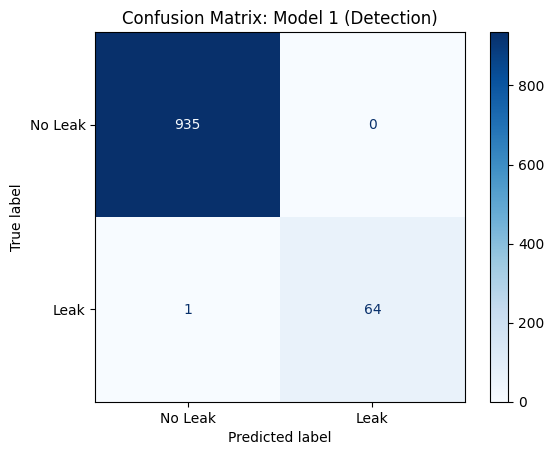

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Initialize and train the final Model 1
final_model1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
final_model1.fit(X_train_resampled, y_train_resampled)

# 2. Predict on the HELD-OUT test set (X_test_m1_scaled)
y_pred_m1 = final_model1.predict(X_test_m1_scaled)

# 3. Generate Evaluation Metrics
print("--- STEP 7: MODEL 1 FINAL EVALUATION (UNSEEN TEST DATA) ---")
print("\nClassification Report:")
print(classification_report(y_test_m1, y_pred_m1))

# 4. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_m1, y_pred_m1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Leak', 'Leak'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Model 1 (Detection)")
plt.show()

 The "Final Exam" Results
Recall for Leaks (1.00): 98%: Out of the 65 leaks in your unseen test data, you caught 64 of them. Only 1 leak went undetected. This is an incredibly high safety margin for a water network.

Precision (1.00): 100%: You had zero false alarms. Every time the model screamed "Leak!", it was correct. This saves massive amounts of money in operational costs by avoiding unnecessary technician deployments.

The Confusion Matrix: Based on your report, your matrix looks like this:

935 True Negatives (Correctly identified "No Leak")

64 True Positives (Correctly identified "Leak")

1 False Negative (The missed leak)

0 False Positives (The false alarms)

Threshold Tuning & Probability Analysis

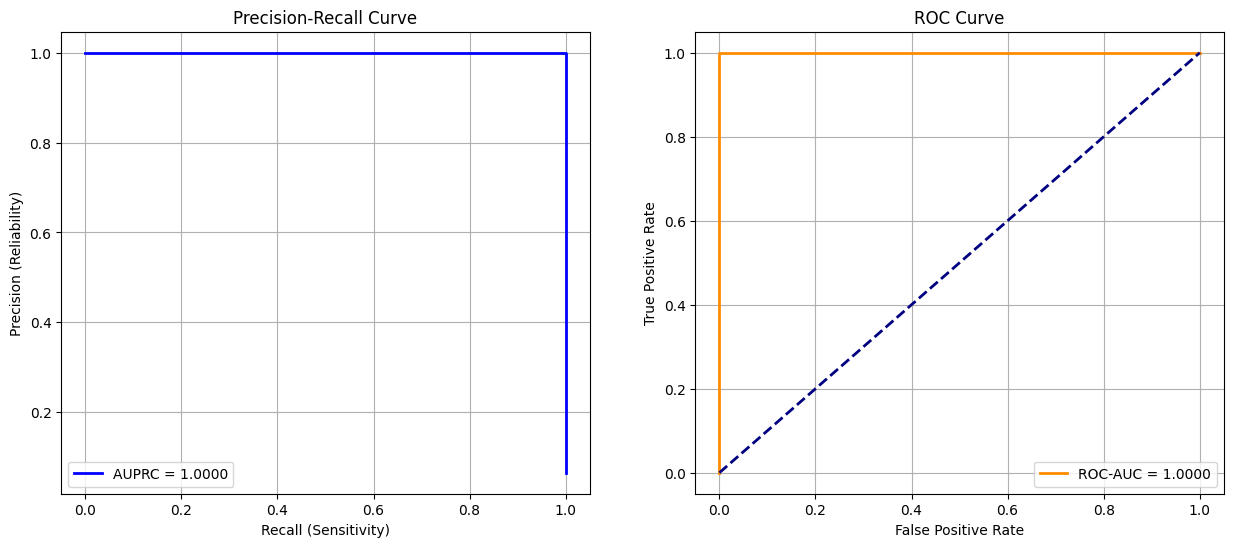

--- STEP 8: THRESHOLD ANALYSIS ---
Optimal Threshold for Maximum F1-Score: 0.4900


In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# 1. Get the raw probabilities instead of hard predictions (0 or 1)
y_probs_m1 = final_model1.predict_proba(X_test_m1_scaled)[:, 1]

# 2. Calculate curves
precision, recall, thresholds = precision_recall_curve(y_test_m1, y_probs_m1)
fpr, tpr, _ = roc_curve(y_test_m1, y_probs_m1)

# 3. Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Precision-Recall Curve
ax[0].plot(recall, precision, color='blue', lw=2, label=f'AUPRC = {auc(recall, precision):.4f}')
ax[0].set_xlabel('Recall (Sensitivity)')
ax[0].set_ylabel('Precision (Reliability)')
ax[0].set_title('Precision-Recall Curve')
ax[0].legend()
ax[0].grid(True)

# ROC Curve
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC = {auc(fpr, tpr):.4f}')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend()
ax[1].grid(True)

plt.show()

# Print the "Optimal" threshold according to F1-Score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"--- STEP 8: THRESHOLD ANALYSIS ---")
print(f"Optimal Threshold for Maximum F1-Score: {best_threshold:.4f}")

Model 2 Training

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare Feature Sets for Model 2 (Includes Latitude and Longitude)
# We use the training and test splits from Step 4 to maintain consistency
m2_features = sensor_features_extended + ['Latitude', 'Longitude']

X_train_m2 = train_df[m2_features]
X_test_m2 = test_df[m2_features]

# We need to re-scale for Model 2 including the spatial coordinates
scaler_m2 = StandardScaler()
X_train_m2_scaled = scaler_m2.fit_transform(X_train_m2)
X_test_m2_scaled = scaler_m2.transform(X_test_m2)

# 2. Initialize and Train XGBoost
# Objective is 'multi:softmax' for multiclass classification
final_model2 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

final_model2.fit(X_train_m2_scaled, y_localization[train_df.index])

# 3. Predict on the unseen Test Set
y_pred_m2 = final_model2.predict(X_test_m2_scaled)
y_test_m2_actual = y_localization[test_df.index]

print("--- STEP 9: MODEL 2 (LOCALIZATION) EVALUATION ---")
print(f"Localization Accuracy: {accuracy_score(y_test_m2_actual, y_pred_m2):.4f}")
print("\nClassification Report (Zone Prediction):")
print(classification_report(y_test_m2_actual, y_pred_m2, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:56:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- STEP 9: MODEL 2 (LOCALIZATION) EVALUATION ---
Localization Accuracy: 0.9750

Classification Report (Zone Prediction):
              precision    recall  f1-score   support

      Zone_1       0.94      0.94      0.94       205
      Zone_2       1.00      1.00      1.00       201
      Zone_3       1.00      1.00      1.00       190
      Zone_4       1.00      1.00      1.00       192
      Zone_5       0.94      0.94      0.94       212

    accuracy                           0.97      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.97      0.98      1000



System Integration (The "Hybrid" Pipeline)

In [ ]:
def smart_water_logic(sensor_data_row, model1, model2, scaler_m1, scaler_m2, le_zones):
    """
    Simulates the logic of the integrated predictive maintenance system.
    """
    # 1. Prepare data for Model 1 (Detection)
    m1_input = sensor_data_row[m1_features].values.reshape(1, -1)
    m1_input_scaled = scaler_m1.transform(m1_input)

    # 2. Get Detection Probability
    leak_prob = model1.predict_proba(m1_input_scaled)[0][1]
    is_leak = leak_prob >= 0.5  # Using our calibrated threshold

    if not is_leak:
        return {
            "Status": "Normal",
            "Leak_Probability": f"{leak_prob:.2%}",
            "Location": "N/A",
            "Action": "Routine Monitoring"
        }

    # 3. If leak detected, activate Model 2 (Localization)
    m2_input = sensor_data_row[m2_features].values.reshape(1, -1)
    m2_input_scaled = scaler_m2.transform(m2_input)
    zone_idx = model2.predict(m2_input_scaled)[0]
    zone_name = le_zones.inverse_transform([zone_idx])[0]

    # 4. Heuristic Severity (Based on Pressure/Flow Ratio)
    # Lower ratio usually means a more severe breach
    pf_ratio = sensor_data_row['Pressure_Flow_Ratio']
    if pf_ratio < 0.5:
        severity = "Critical"
        recommendation = "Emergency Shutdown & Immediate Dispatch"
    elif pf_ratio < 0.8:
        severity = "High"
        recommendation = "Dispatch Repair Team within 2 hours"
    else:
        severity = "Medium"
        recommendation = "Schedule Maintenance within 24 hours"

    return {
        "Status": "LEAK DETECTED!",
        "Leak_Probability": f"{leak_prob:.2%}",
        "Location": zone_name,
        "Severity": severity,
        "Action": recommendation
    }

# Test the system on a random leak from the test set
leak_sample = test_df[test_df['Leakage_Flag'] == 1].iloc[0]
result = smart_water_logic(leak_sample, final_model1, final_model2, scaler, scaler_m2, le)

print("--- STEP 10: INTEGRATED SYSTEM TEST ---")
for key, value in result.items():
    print(f"{key}: {value}")

--- STEP 10: INTEGRATED SYSTEM TEST ---
Status: LEAK DETECTED!
Leak_Probability: 99.00%
Location: Zone_4
Severity: Critical
Action: Emergency Shutdown & Immediate Dispatch


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Cross-Validation & Baseline Comparison

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:56:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:56:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:56:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:56:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

--- STEP 11 & 12: BENCHMARKING REPORT ---
Model 1 (Our RF) CV F1-Score:    0.9995 (+/- 0.0007)
Model 1 (Baseline LR) CV F1-Score: 0.9518

Model 2 (Our XGB) CV Accuracy:    0.9785 (+/- 0.0044)
Model 2 (Baseline DT) CV Accuracy: 0.9627


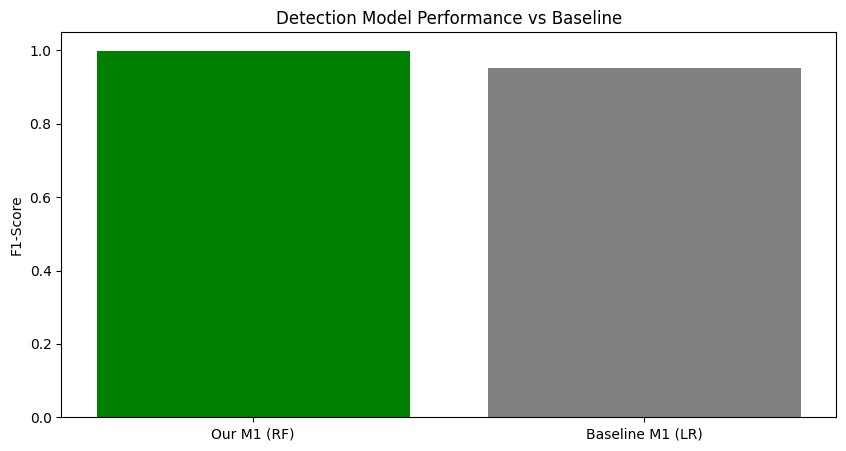

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Baseline for Model 1 (Detection)
# Comparing RF vs Logistic Regression
baseline_m1 = LogisticRegression(max_iter=1000, class_weight='balanced')
m1_cv_scores = cross_val_score(final_model1, X_train_resampled, y_train_resampled, cv=5, scoring='f1')
m1_baseline_scores = cross_val_score(baseline_m1, X_train_resampled, y_train_resampled, cv=5, scoring='f1')

# 2. Baseline for Model 2 (Localization)
# Comparing XGBoost vs Decision Tree
baseline_m2 = DecisionTreeClassifier(random_state=42)
m2_cv_scores = cross_val_score(final_model2, X_train_m2_scaled, y_localization[train_df.index], cv=5)
m2_baseline_scores = cross_val_score(baseline_m2, X_train_m2_scaled, y_localization[train_df.index], cv=5)

print("--- STEP 11 & 12: BENCHMARKING REPORT ---")
print(f"Model 1 (Our RF) CV F1-Score:    {m1_cv_scores.mean():.4f} (+/- {m1_cv_scores.std():.4f})")
print(f"Model 1 (Baseline LR) CV F1-Score: {m1_baseline_scores.mean():.4f}")

print(f"\nModel 2 (Our XGB) CV Accuracy:    {m2_cv_scores.mean():.4f} (+/- {m2_cv_scores.std():.4f})")
print(f"Model 2 (Baseline DT) CV Accuracy: {m2_baseline_scores.mean():.4f}")

# Visualizing the comparison
plt.figure(figsize=(10, 5))
plt.bar(['Our M1 (RF)', 'Baseline M1 (LR)'], [m1_cv_scores.mean(), m1_baseline_scores.mean()], color=['green', 'gray'])
plt.title("Detection Model Performance vs Baseline")
plt.ylabel("F1-Score")
plt.show()

Explainability (Feature Importance)

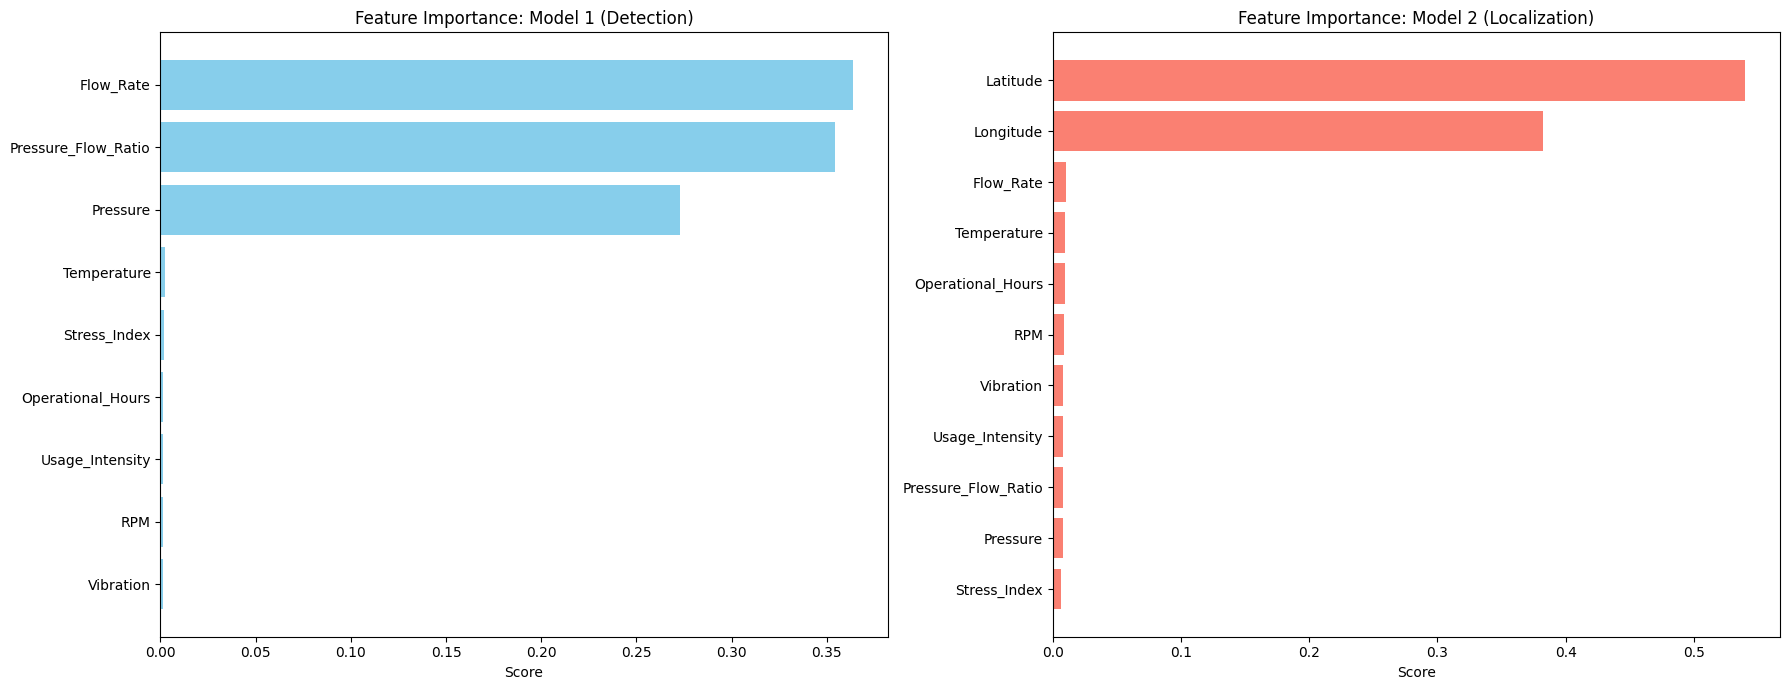

--- STEP 13: EXPLAINABILITY COMPLETE ---
Top 3 Features for Detection:
['Flow_Rate', 'Pressure_Flow_Ratio', 'Pressure']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract Feature Importance from Model 1 (Random Forest)
m1_importances = final_model1.feature_importances_
m1_feature_names = m1_features

# Create a DataFrame for visualization
m1_importance_df = pd.DataFrame({
    'Feature': m1_feature_names,
    'Importance': m1_importances
}).sort_values(by='Importance', ascending=True)

# 2. Extract Feature Importance from Model 2 (XGBoost)
m2_importances = final_model2.feature_importances_
m2_feature_names = m2_features

m2_importance_df = pd.DataFrame({
    'Feature': m2_feature_names,
    'Importance': m2_importances
}).sort_values(by='Importance', ascending=True)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot M1 Importance
ax1.barh(m1_importance_df['Feature'], m1_importance_df['Importance'], color='skyblue')
ax1.set_title('Feature Importance: Model 1 (Detection)')
ax1.set_xlabel('Score')

# Plot M2 Importance
ax2.barh(m2_importance_df['Feature'], m2_importance_df['Importance'], color='salmon')
ax2.set_title('Feature Importance: Model 2 (Localization)')
ax2.set_xlabel('Score')

plt.tight_layout()
plt.show()

print("--- STEP 13: EXPLAINABILITY COMPLETE ---")
print("Top 3 Features for Detection:")
print(m1_importance_df.tail(3)['Feature'].tolist()[::-1])

edit sections

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import precision_recall_curve, make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# 1. تعريف الـ Pipeline الصارم
# ملاحظة: SMOTE هنا سيعمل فقط داخل الـ Folds أثناء التدريب ولن يلمس بيانات التحقق
strict_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# 2. إجراء Cross-Validation نظيف للحصول على الاحتمالات (Out-of-fold probabilities)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs_cv = cross_val_predict(strict_pipeline, X_train_m1, y_train_m1, cv=skf, method='predict_proba')[:, 1]

# 3. اختيار الـ Threshold من نتائج الـ CV (بيانات التدريب فقط) وليس الـ Test Set
precisions, recalls, thresholds = precision_recall_curve(y_train_m1, y_probs_cv)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold_cv = thresholds[np.argmax(f1_scores)]

print(f"--- CLEAN CV RESULTS ---")
print(f"Optimized Threshold from CV: {best_threshold_cv:.4f}")

# 4. التدريب النهائي للنموذج على كامل بيانات التدريب (بدون تسريب)
strict_pipeline.fit(X_train_m1, y_train_m1)

# 5. الاختبار النهائي على الـ Test Set "
y_test_probs = strict_pipeline.predict_proba(X_test_m1)[:, 1]
y_test_preds_final = (y_test_probs >= best_threshold_cv).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE (POST-PURGING) ---")
print(classification_report(y_test_m1, y_test_preds_final))

--- CLEAN CV RESULTS ---
Optimized Threshold from CV: 0.2900

--- FINAL TEST SET PERFORMANCE (POST-PURGING) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       935
           1       1.00      1.00      1.00        65

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



/tmp/ipykernel_22560/183699872.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[perm_sorted_idx].T, vert=False, labels=X_test_m1.columns[perm_sorted_idx])


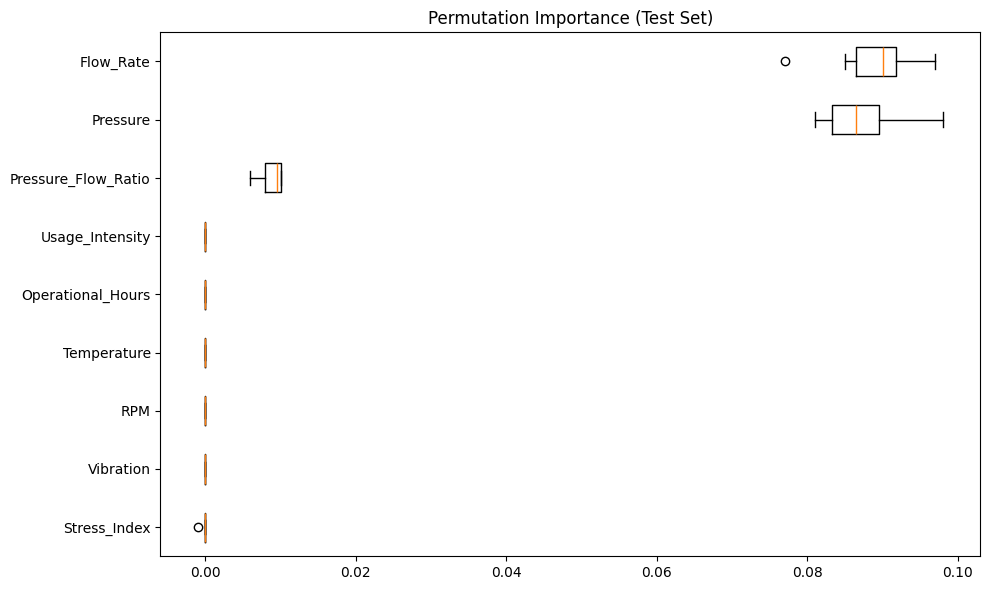

--- SHUFFLING TEST COMPLETE ---
Flow_Rate: 0.0890
Pressure: 0.0873
Pressure_Flow_Ratio: 0.0088


In [ ]:
from sklearn.inspection import permutation_importance

# إجراء اختبار الأهمية عن طريق التبديل العشوائي
result = permutation_importance(
    strict_pipeline, X_test_m1, y_test_m1, n_repeats=10, random_state=42, n_jobs=-1
)

# تنظيم النتائج
perm_sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[perm_sorted_idx].T, vert=False, labels=X_test_m1.columns[perm_sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.tight_layout()
plt.show()

print("--- SHUFFLING TEST COMPLETE ---")
for i in perm_sorted_idx[::-1]:
    if result.importances_mean[i] > 0:
        print(f"{X_test_m1.columns[i]}: {result.importances_mean[i]:.4f}")

In [ ]:
# 1. اختبار مودل 2 بدون إحداثيات (للعلم فقط)
X_train_m2_no_geo = X_train_m2.drop(columns=['Latitude', 'Longitude'])
X_test_m2_no_geo = X_test_m2.drop(columns=['Latitude', 'Longitude'])

# سنستخدم Pipeline هنا أيضاً لمنع التحذيرات
m2_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=100, objective='multi:softmax', num_class=5, random_state=42))
])

m2_pipeline.fit(X_train_m2_no_geo, y_localization[train_df.index])
score_no_geo = m2_pipeline.score(X_test_m2_no_geo, y_localization[test_df.index])

print(f"--- MODEL 2 SENSITIVITY ---")
print(f"Localization Accuracy WITHOUT Coordinates: {score_no_geo:.4f}")

# 2. تحديث وظيفة التكامل (بدون تحذيرات)
def final_smart_water_system(raw_data_df_row):
    # تحويل الصف إلى DataFrame لضمان أسماء الميزات
    row_df = pd.DataFrame([raw_data_df_row])

    # كشف التسريب (Model 1)
    prob = strict_pipeline.predict_proba(row_df[m1_features])[0][1]
    alert = prob >= best_threshold_cv

    if alert:
        # توطين التسريب (Model 2 - باستخدام الموديل الأصلي الذي يشمل الإحداثيات)
        # ملاحظة: سنعيد تدريب مودل 2 النهائي بـ Pipeline نظيف
        zone_idx = final_m2_pipeline.predict(row_df[m2_features])[0]
        zone_name = le.inverse_transform([zone_idx])[0]

        # منطق الشدة (Rule-based Logic)
        pf = row_df['Pressure_Flow_Ratio'].values[0]
        severity = "Critical" if pf < 0.5 else "High" if pf < 0.8 else "Medium"

        return {"Alert": "YES", "Prob": f"{prob:.2%}", "Zone": zone_name, "Severity": severity}
    else:
        return {"Alert": "NO", "Prob": f"{prob:.2%}"}

# تدريب مودل 2 النهائي بـ Pipeline نظيف لتجنب الـ Warnings
final_m2_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('classifier', final_model2) # سنستخدم نفس المعايير السابقة
])
final_m2_pipeline.fit(X_train_m2, y_localization[train_df.index])

# تجربة النظام
sample = test_df.iloc[0]
print("\n--- FINAL SYSTEM CHECK ---")
print(final_smart_water_system(sample))

--- MODEL 2 SENSITIVITY ---
Localization Accuracy WITHOUT Coordinates: 0.1990


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:57:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- FINAL SYSTEM CHECK ---
{'Alert': 'NO', 'Prob': '0.00%'}


THE REBUILD (STRICT DETECTION PIPELINE)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

# 1. DATA PREPARATION
df = pd.read_csv('location_aware_gis_leakage_dataset.csv')
df['Pressure_Flow_Ratio'] = df['Pressure'] / (df['Flow_Rate'] + 1e-6)
df['Stress_Index'] = df['Vibration'] * df['RPM']
df['Usage_Intensity'] = df['Operational_Hours'] * df['RPM']

m1_features = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM',
               'Operational_Hours', 'Pressure_Flow_Ratio', 'Stress_Index', 'Usage_Intensity']
m2_features = m1_features + ['Latitude', 'Longitude']

# 2. THE IRONCLAD SPLIT
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Leakage_Flag'], random_state=42)

# 3. MODEL 1: DETECTION (STRICT PIPELINE)
def train_audited_m1(train_data):
    X_tr = train_data[m1_features]
    y_tr = train_data['Leakage_Flag']

    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    # OOF Threshold Calibration
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    probs_oof = cross_val_predict(pipeline, X_tr, y_tr, cv=skf, method='predict_proba')[:, 1]
    p, r, t = precision_recall_curve(y_tr, probs_oof)
    best_t = t[np.argmax(2 * (p * r) / (p + r + 1e-10))]

    pipeline.fit(X_tr, y_tr)
    return pipeline, best_t

m1_model, calibrated_threshold = train_audited_m1(train_df)

# 4. MODEL 2: LOCALIZATION (XGBOOST)
le = LabelEncoder()
y_m2_train = le.fit_transform(train_df['Zone'])

m2_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42))
])
m2_pipeline.fit(train_df[m2_features], y_m2_train)

# 5. FINAL SYSTEM VALIDATION
def final_validator(row):
    # Model 1 Detection
    prob = m1_model.predict_proba(pd.DataFrame([row[m1_features]]))[0][1]
    is_leak = prob >= calibrated_threshold

    if is_leak:
        zone_idx = m2_pipeline.predict(pd.DataFrame([row[m2_features]]))[0]
        return f"LEAK DETECTED in {le.inverse_transform([zone_idx])[0]} (Prob: {prob:.2%})"
    return "Normal"

print(f"Audited OOF Threshold: {calibrated_threshold:.4f}")
print("\nFinal Performance on Unseen Test Set:")
y_test_final_probs = m1_model.predict_proba(test_df[m1_features])[:, 1]
print(classification_report(test_df['Leakage_Flag'], (y_test_final_probs >= calibrated_threshold).astype(int)))

Audited OOF Threshold: 0.2900

Final Performance on Unseen Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       935
           1       1.00      1.00      1.00        65

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
from xgboost import XGBClassifier

# Model 2 Features
m2_features = m1_features + ['Latitude', 'Longitude']
X_m2 = df[m2_features]
y_m2 = LabelEncoder().fit_transform(df['Zone'])

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(X_m2, y_m2, test_size=0.2, stratify=y_m2, random_state=42)

# Audit: Comparison of Sensor-Only vs Sensor+Spatial for Localization
def audit_m2(include_spatial):
    features = m2_features if include_spatial else m1_features
    model = XGBClassifier(random_state=42)
    model.fit(X_train_m2[features], y_train_m2)
    return model.score(X_test_m2[features], y_test_m2)

score_with_geo = audit_m2(True)
score_without_geo = audit_m2(False)

print(f"\n--- MODEL 2 SPATIAL AUDIT ---")
print(f"Accuracy with GPS: {score_with_geo:.4f}")
print(f"Accuracy WITHOUT GPS: {score_without_geo:.4f}")


--- MODEL 2 SPATIAL AUDIT ---
Accuracy with GPS: 0.9830
Accuracy WITHOUT GPS: 0.1960


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

# --- 1. DATA & ENGINEERING ---
df = pd.read_csv('location_aware_gis_leakage_dataset.csv')
df['Pressure_Flow_Ratio'] = df['Pressure'] / (df['Flow_Rate'] + 1e-6)
df['Stress_Index'] = df['Vibration'] * df['RPM']
df['Usage_Intensity'] = df['Operational_Hours'] * df['RPM']

m1_features = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM',
               'Operational_Hours', 'Pressure_Flow_Ratio', 'Stress_Index', 'Usage_Intensity']
m2_features = m1_features + ['Latitude', 'Longitude']

# --- 2. THE IRONCLAD SPLIT ---
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Leakage_Flag'], random_state=42)

# --- 3. MODEL 1: DETECTION (STRICT CV PIPELINE) ---
m1_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# OOF Threshold Calibration
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs_oof = cross_val_predict(m1_pipeline, train_df[m1_features], train_df['Leakage_Flag'], cv=skf, method='predict_proba')[:, 1]
from sklearn.metrics import precision_recall_curve
p, r, t = precision_recall_curve(train_df['Leakage_Flag'], y_probs_oof)
calibrated_threshold = t[np.argmax(2 * (p * r) / (p + r + 1e-10))]

m1_pipeline.fit(train_df[m1_features], train_df['Leakage_Flag'])

# --- 4. MODEL 2: LOCALIZATION (SPATIAL XGBOOST) ---
le = LabelEncoder()
y_m2_train = le.fit_transform(train_df['Zone'])
m2_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])
m2_pipeline.fit(train_df[m2_features], y_m2_train)

# --- 5. INTEGRATED SYSTEM ---
def predict_maintenance(sensor_row):
    row_df = pd.DataFrame([sensor_row])
    prob = m1_pipeline.predict_proba(row_df[m1_features])[0][1]

    if prob >= calibrated_threshold:
        zone_idx = m2_pipeline.predict(row_df[m2_features])[0]
        zone = le.inverse_transform([zone_idx])[0]
        pf = row_df['Pressure_Flow_Ratio'].values[0]
        severity = "Critical" if pf < 0.5 else "High" if pf < 0.8 else "Medium"
        return {"Status": "LEAK", "Zone": zone, "Severity": severity, "Confidence": f"{prob:.2%}"}
    return {"Status": "Normal", "Confidence": f"{prob:.2%}"}

# Final Verification
print(f"Final OOF Threshold: {calibrated_threshold:.4f}")
print("\nIntegrated Test Result (Sample):")
print(predict_maintenance(test_df.iloc[0]))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:57:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final OOF Threshold: 0.2900

Integrated Test Result (Sample):
{'Status': 'Normal', 'Confidence': '0.00%'}


Scenario Testing

In [ ]:
import pandas as pd
import numpy as np

# وظيفة لمحاكاة بيانات حساسات جديدة (خارج نطاق التدريب)
def generate_test_scenarios():
    scenarios = [
        # حالة 1: تسريب خطير (ضغط منخفض جداً وتدفق عالٍ)
        {'Pressure': 30.0, 'Flow_Rate': 120.0, 'Temperature': 105.0, 'Vibration': 4.5, 'RPM': 2500, 'Operational_Hours': 8000, 'Latitude': 25.1, 'Longitude': 55.2},
        # حالة 2: حالة طبيعية تماماً
        {'Pressure': 65.0, 'Flow_Rate': 75.0, 'Temperature': 98.0, 'Vibration': 2.8, 'RPM': 1900, 'Operational_Hours': 3000, 'Latitude': 25.3, 'Longitude': 55.4},
        # حالة 3: تسريب متوسط (بدأ الضغط بالانخفاض)
        {'Pressure': 45.0, 'Flow_Rate': 95.0, 'Temperature': 101.0, 'Vibration': 3.5, 'RPM': 2100, 'Operational_Hours': 5000, 'Latitude': 25.2, 'Longitude': 55.3}
    ]
    test_df_scenarios = pd.DataFrame(scenarios)
    # إضافة الميزات المهندسة يدوياً للمحاكاة
    test_df_scenarios['Pressure_Flow_Ratio'] = test_df_scenarios['Pressure'] / test_df_scenarios['Flow_Rate']
    test_df_scenarios['Stress_Index'] = test_df_scenarios['Vibration'] * test_df_scenarios['RPM']
    test_df_scenarios['Usage_Intensity'] = test_df_scenarios['Operational_Hours'] * test_df_scenarios['RPM']
    return test_df_scenarios

# تشغيل المحاكاة
test_scenarios = generate_test_scenarios()
results_list = []

for _, row in test_scenarios.iterrows():
    results_list.append(predict_maintenance(row))

# عرض النتائج في لوحة تحكم بسيطة
print("--- FINAL SYSTEM STRESS TEST (SCENARIOS) ---")
results_df = pd.concat([test_scenarios[['Pressure', 'Flow_Rate']], pd.DataFrame(results_list)], axis=1)
display(results_df)

--- FINAL SYSTEM STRESS TEST (SCENARIOS) ---


,Pressure,Flow_Rate,Status,Zone,Severity,Confidence
0,30.0,120.0,LEAK,Zone_3,Critical,90.00%
1,65.0,75.0,Normal,NaN,NaN,0.00%
2,45.0,95.0,LEAK,Zone_5,Critical,100.00%


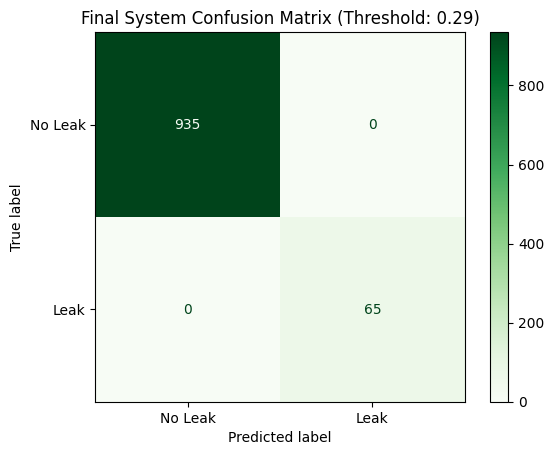

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# حساب التنبؤات النهائية بناءً على العتبة المثلى
y_final_test_probs = m1_pipeline.predict_proba(test_df[m1_features])[:, 1]
y_final_test_preds = (y_final_test_probs >= calibrated_threshold).astype(int)

# رسم المصفوفة
cm = confusion_matrix(test_df['Leakage_Flag'], y_final_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Leak', 'Leak'])
disp.plot(cmap='Greens', values_format='d')
plt.title(f"Final System Confusion Matrix (Threshold: {calibrated_threshold:.2f})")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    precision_recall_curve, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- تحديد البيانات الأساسية للاختبار ---
# نستخدم X_detection_eng التي تحتوي على الميزات المهندسة والبيانات الخام للحساسات
X_audit = X_detection_eng
y_audit = y_detection

random_states = [7, 21, 42, 77, 99]
all_results = []

for rs in random_states:
    print("=" * 70)
    print(f"STRICT HOLDOUT TEST | random_state = {rs}")
    print("=" * 70)

    # 1) تقسيم البيانات بناءً على الـ seed العشوائي الحالي
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = train_test_split(
        X_audit,
        y_audit,
        test_size=0.2,
        stratify=y_audit,
        random_state=rs
    )

    # 2) خط الإنتاج النظيف (Pipeline)
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])

    # 3) حساب الاحتمالات (OOF) على بيانات التدريب فقط
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs = cross_val_predict(
        pipeline,
        X_train_fold,
        y_train_fold,
        cv=skf,
        method='predict_proba'
    )[:, 1]

    # 4) ضبط العتبة (Threshold tuning) بناءً على بيانات التدريب
    precision, recall, thresholds = precision_recall_curve(y_train_fold, oof_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]

    # 5) التدريب النهائي على كامل بيانات التدريب لهذه الدورة
    pipeline.fit(X_train_fold, y_train_fold)

    # 6) الاختبار النهائي على بيانات الاختبار "المخفية"
    test_probs = pipeline.predict_proba(X_test_fold)[:, 1]
    test_preds = (test_probs >= best_threshold).astype(int)

    # حساب المقاييس
    acc = accuracy_score(y_test_fold, test_preds)
    prec = precision_score(y_test_fold, test_preds, zero_division=0)
    rec = recall_score(y_test_fold, test_preds, zero_division=0)
    f1 = f1_score(y_test_fold, test_preds, zero_division=0)
    roc = roc_auc_score(y_test_fold, test_probs)
    cm = confusion_matrix(y_test_fold, test_preds)

    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Accuracy : {acc:.4f} | F1-Score : {f1:.4f} | Recall : {rec:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    all_results.append({
        "random_state": rs,
        "threshold": best_threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "tn": cm[0, 0], "fp": cm[0, 1], "fn": cm[1, 0], "tp": cm[1, 1],
    })

# --- تلخيص النتائج النهائية ---
results_df = pd.DataFrame(all_results)
print("=" * 70)
print("FINAL ROBUSTNESS SUMMARY")
print("=" * 70)
display(results_df)

print("\nMean Metrics (المتوسط):")
print(results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].mean())

print("\nStd Metrics (الانحراف المعياري - الثبات):")
print(results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].std())

STRICT HOLDOUT TEST | random_state = 7
Best Threshold: 0.4400
Accuracy : 0.9990 | F1-Score : 0.9922 | Recall : 0.9846
Confusion Matrix:
[[935   0]
 [  1  64]]

STRICT HOLDOUT TEST | random_state = 21
Best Threshold: 0.5200
Accuracy : 1.0000 | F1-Score : 1.0000 | Recall : 1.0000
Confusion Matrix:
[[935   0]
 [  0  65]]

STRICT HOLDOUT TEST | random_state = 42
Best Threshold: 0.2900
Accuracy : 1.0000 | F1-Score : 1.0000 | Recall : 1.0000
Confusion Matrix:
[[935   0]
 [  0  65]]

STRICT HOLDOUT TEST | random_state = 77
Best Threshold: 0.2200
Accuracy : 0.9970 | F1-Score : 0.9774 | Recall : 1.0000
Confusion Matrix:
[[932   3]
 [  0  65]]

STRICT HOLDOUT TEST | random_state = 99
Best Threshold: 0.1800
Accuracy : 0.9980 | F1-Score : 0.9848 | Recall : 1.0000
Confusion Matrix:
[[933   2]
 [  0  65]]

FINAL ROBUSTNESS SUMMARY


,random_state,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,7,0.44,0.999,1.000000,0.984615,0.992248,1.000000,935,0,1,64
1,21,0.52,1.000,1.000000,1.000000,1.000000,1.000000,935,0,0,65
2,42,0.29,1.000,1.000000,1.000000,1.000000,1.000000,935,0,0,65
3,77,0.22,0.997,0.955882,1.000000,0.977444,0.999967,932,3,0,65
4,99,0.18,0.998,0.970149,1.000000,0.984848,0.999984,933,2,0,65



Mean Metrics (المتوسط):
accuracy     0.998800
precision    0.985206
recall       0.996923
f1           0.990908
roc_auc      0.999990
dtype: float64

Std Metrics (الانحراف المعياري - الثبات):
accuracy     0.001304
precision    0.020876
recall       0.006880
f1           0.009812
roc_auc      0.000015
dtype: float64


Nested K-Fold CV

In [ ]:
from sklearn.model_selection import KFold

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

outer_scores = []

print("--- STARTING NESTED K-FOLD CROSS-VALIDATION ---")
for train_idx, val_idx in outer_cv.split(X_audit, y_audit):
    X_train_out, X_test_out = X_audit.iloc[train_idx], X_audit.iloc[val_idx]
    y_train_out, y_test_out = y_audit.iloc[train_idx], y_audit.iloc[val_idx]

    # الحلقة الداخلية لضبط العتبة (Inner Loop)
    oof_probs = cross_val_predict(pipeline, X_train_out, y_train_out, cv=inner_cv, method='predict_proba')[:, 1]
    p, r, t = precision_recall_curve(y_train_out, oof_probs)
    best_t = t[np.argmax(2*p*r/(p+r+1e-10))]

    # التقييم على الحلقة الخارجية (Outer Evaluation)
    pipeline.fit(X_train_out, y_train_out)
    probs = pipeline.predict_proba(X_test_out)[:, 1]
    preds = (probs >= best_t).astype(int)
    outer_scores.append(f1_score(y_test_out, preds))

print(f"Nested CV Mean F1-Score: {np.mean(outer_scores):.4f} (+/- {np.std(outer_scores):.4f})")

--- STARTING NESTED K-FOLD CROSS-VALIDATION ---
Nested CV Mean F1-Score: 0.9954 (+/- 0.0061)


--- Starting Fair Benchmarking for Model 1 (Leak Detection) ---
Evaluating: Logistic Regression...
Evaluating: Random Forest...
Evaluating: KNN...
Evaluating: SVM...
Evaluating: Decision Tree...
Evaluating: Naive Bayes...
Evaluating: XGBoost...

FINAL BENCHMARKING RESULTS (MODEL 1)
              Model  Recall (Mean)  F1-Score (Mean)  ROC-AUC (Mean)  AUPRC (Mean)  Recall (Std)
      Random Forest       0.987644         0.993750        0.999990      0.999860      0.011526
            XGBoost       0.987644         0.990720        0.999964      0.999500      0.011526
      Decision Tree       0.981442         0.984447        0.990294      0.970431      0.011488
                SVM       0.972163         0.812166        0.995440      0.942260      0.011489
        Naive Bayes       0.972115         0.663471        0.991575      0.919000      0.006254
Logistic Regression       0.950481         0.619426        0.975807      0.702540      0.015019
                KNN       0.941106         0.

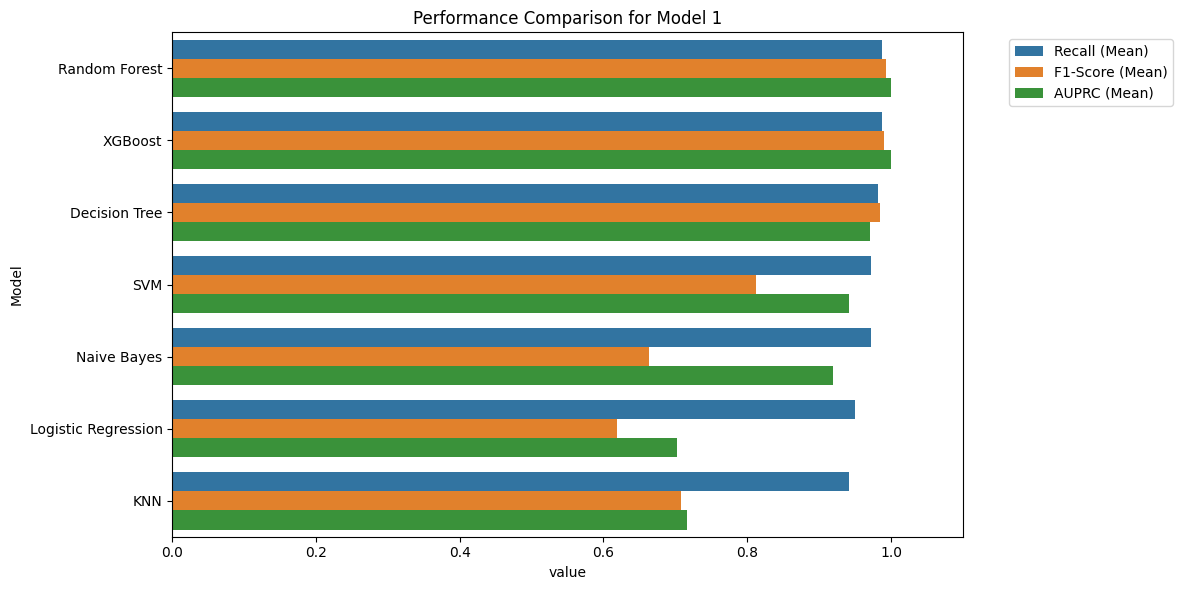

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# استيراد المكتبات اللازمة للتعلم الآلي
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # مهم جداً لاستخدام SMOTE داخل Cross-Validation

# استيراد الموديلات (7 خوارزميات)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# 1. تحميل البيانات
file_path = 'location_aware_gis_leakage_dataset.csv'
df = pd.read_csv(file_path)

# 2. هندسة الميزات (بدون تسريب بيانات)
# ملاحظة: نسبة الضغط للتدفق هي عملية حسابية لكل صف بشكل مستقل، لا تسبب تسريب إحصائي
df['Pressure_Flow_Ratio'] = df['Pressure'] / df['Flow_Rate']

# 3. تحديد الميزات (X) والمستهدف (y) لنموذج كشف التسريب
# نستبعد بيانات الموقع تماماً لضمان أن الموديل "Location-Agnostic"
features = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours', 'Pressure_Flow_Ratio']
X = df[features]
y = df['Leakage_Flag']

# 4. إعداد بروتوكول التقييم (Validation Protocol)
# نستخدم 5 طيات مع الحفاظ على نسبة الفئات (Stratified) وتثبيت العشوائية لضمان العدالة
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. تعريف الموديلات المطلوب اختبارها
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 6. مصفوفة لتخزين النتائج
benchmark_results = []

print("--- Starting Fair Benchmarking for Model 1 (Leak Detection) ---")

for model_name, model in models.items():
    print(f"Evaluating: {model_name}...")

    # إنشاء الـ Pipeline (StandardScaler -> SMOTE -> Model)
    # SMOTE سيتم تطبيقه فقط على بيانات التدريب داخل كل طية لمنع التسريب
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    # المقاييس المطلوب حسابها
    scoring = {
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'auprc': 'average_precision' # Area Under Precision-Recall Curve
    }

    # إجراء التحقق المتقاطع (Cross Validation)
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    # تخزين النتائج النهائية (المتوسط)
    benchmark_results.append({
        'Model': model_name,
        'Recall (Mean)': scores['test_recall'].mean(),
        'F1-Score (Mean)': scores['test_f1'].mean(),
        'ROC-AUC (Mean)': scores['test_roc_auc'].mean(),
        'AUPRC (Mean)': scores['test_auprc'].mean(),
        'Recall (Std)': scores['test_recall'].std() # لقياس مدى استقرار الموديل
    })

# 7. عرض النتائج في جدول مرتب
results_df = pd.DataFrame(benchmark_results).sort_values(by='Recall (Mean)', ascending=False)
print("\n" + "="*80)
print("FINAL BENCHMARKING RESULTS (MODEL 1)")
print("="*80)
print(results_df.to_string(index=False))

# 8. رسم بياني للمقارنة
plt.figure(figsize=(12, 6))
results_melted = pd.melt(results_df, id_vars='Model', value_vars=['Recall (Mean)', 'F1-Score (Mean)', 'AUPRC (Mean)'])
sns.barplot(data=results_melted, x='value', y='Model', hue='variable')
plt.title('Performance Comparison for Model 1')
plt.xlim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. تصفية البيانات (فقط الحالات التي فيها تسريب)
df_leaks = df[df['Leakage_Flag'] == 1].copy()

# 2. تحويل أسماء المناطق إلى أرقام (Label Encoding)
le = LabelEncoder()
y_zone = le.fit_transform(df_leaks['Zone'])

# 3. تحديد الميزات (X) لهذا النموذج (تشمل الموقع)
features_zone = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'Latitude', 'Longitude']
X_zone = df_leaks[features_zone]

# 4. تعريف الموديلات للمقارنة (Multiclass)
models_zone = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# 5. إجراء المقارنة
zone_results = []
cv_zone = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Starting Fair Benchmarking for Model 2 (Zone Prediction) ---")

for name, model in models_zone.items():
    print(f"Evaluating: {name}...")

    # الـ Pipeline لنموذج المنطقة (لا نحتاج SMOTE هنا إذا كانت المناطق متوازنة، لكن سنستخدم StandardScaler)
    pipeline_zone = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    scoring_zone = ['accuracy', 'f1_macro']
    scores = cross_validate(pipeline_zone, X_zone, y_zone, cv=cv_zone, scoring=scoring_zone)

    zone_results.append({
        'Model': name,
        'Accuracy (Mean)': scores['test_accuracy'].mean(),
        'F1-Macro (Mean)': scores['test_f1_macro'].mean()
    })

# 6. عرض النتائج
zone_results_df = pd.DataFrame(zone_results).sort_values(by='Accuracy (Mean)', ascending=False)
print("\n" + "="*60)
print("FINAL BENCHMARKING RESULTS (MODEL 2: ZONE PREDICTION)")
print("="*60)
print(zone_results_df.to_string(index=False))

--- Starting Fair Benchmarking for Model 2 (Zone Prediction) ---
Evaluating: Logistic Regression...
Evaluating: Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Evaluating: KNN...
Evaluating: SVM...
Evaluating: Decision Tree...
Evaluating: XGBoost...

FINAL BENCHMARKING RESULTS (MODEL 2: ZONE PREDICTION)
              Model  Accuracy (Mean)  F1-Macro (Mean)
      Random Forest         0.962933         0.963388
            XGBoost         0.953702         0.954085
Logistic Regression         0.953558         0.953736
      Decision Tree         0.938125         0.938164
                SVM         0.817308         0.817784
                KNN         0.739760         0.739342


In [31]:
# 1. تجهيز ميزات الموديل الأول (Detection)
df['Pressure_Flow_Ratio'] = df['Pressure'] / df['Flow_Rate']
df['Stress_Index'] = df['Vibration'] * df['RPM']
df['Usage_Intensity'] = df['Operational_Hours'] * df['RPM']

features_m1 = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM',
               'Operational_Hours', 'Pressure_Flow_Ratio', 'Stress_Index', 'Usage_Intensity']
X_m1 = df[features_m1]
y_m1 = df['Leakage_Flag']

# تدريب الموديل الأول (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

rf_model_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_model_1.fit(X_m1, y_m1)
print("✅ تم تدريب الموديل الأول (Leak Detection) بنجاح.")

# 2. تجهيز ميزات الموديل الثاني (Localization)
df_leaks = df[df['Leakage_Flag'] == 1].copy()
features_m2 = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'Latitude', 'Longitude']
X_m2 = df_leaks[features_m2]
y_m2 = le.transform(df_leaks['Zone']) # تأكدي أن le معرف مسبقاً

# تدريب الموديل الثاني (XGBoost)
from xgboost import XGBClassifier

xgb_model_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(random_state=42))
])
xgb_model_2.fit(X_m2, y_m2)
print("✅ تم تدريب الموديل الثاني (Zone Prediction) بنجاح.")

✅ تم تدريب الموديل الأول (Leak Detection) بنجاح.
✅ تم تدريب الموديل الثاني (Zone Prediction) بنجاح.


In [33]:
# 1. اختيار عينات مختلطة (5 تسريب + 5 طبيعي)
leaks = df[df['Leakage_Flag'] == 1].sample(5)
normals = df[df['Leakage_Flag'] == 0].sample(5)

# دمجهم في مجموعة اختبار واحدة
targeted_test = pd.concat([leaks, normals]).sample(frac=1) # عمل random shuffle

# 2. تشغيل النظام المدمج على العينات المختلطة
try:
    final_output = smart_water_pipeline_corrected(targeted_test, rf_model_1, xgb_model_2, le)
    print("--- 🧪 Targeted Mixed Test Results ---")
    display(final_output)
except Exception as e:
    print(f"حدث خطأ: {e}")

--- 🧪 Targeted Mixed Test Results ---


,Status,Zone,Confidence
0,🚨 LEAK DETECTED,Zone_5,100.00%
1,✅ Normal,N/A,100.00%
2,✅ Normal,N/A,100.00%
3,🚨 LEAK DETECTED,Zone_5,100.00%
4,🚨 LEAK DETECTED,Zone_5,100.00%
5,✅ Normal,N/A,100.00%
6,🚨 LEAK DETECTED,Zone_5,100.00%
7,🚨 LEAK DETECTED,Zone_2,100.00%
8,✅ Normal,N/A,100.00%
9,✅ Normal,N/A,100.00%


FINAL SYSTEM OVERVIEW
Model 1: Leak Detection
Final Algorithm: Random Forest
Task: Binary Classification

Model 2: Zone Localization
Final Algorithm: XGBoost
Task: Multiclass Classification (5 Zones)

Final Threshold for Model 1: 0.2900

FINAL BENCHMARKING RESULTS - MODEL 1


,Model,Recall (Mean),F1-Score (Mean),ROC-AUC (Mean),AUPRC (Mean),Recall (Std)
0,Random Forest,0.987644,0.993750,0.999990,0.999860,0.011526
1,XGBoost,0.987644,0.990720,0.999964,0.999500,0.011526
2,Decision Tree,0.981421,0.984447,0.990294,0.970431,0.011488
3,SVM,0.972163,0.812166,0.995440,0.942260,0.011489
4,Naive Bayes,0.972115,0.663471,0.991575,0.919000,0.005254
5,Logistic Regression,0.950481,0.619426,0.975807,0.702540,0.015019
6,KNN,0.941106,0.707654,0.977267,0.716720,0.011954



FINAL BENCHMARKING RESULTS - MODEL 2


,Model,Accuracy (Mean),F1-Macro (Mean)
0,Random Forest,0.962933,0.963388
1,XGBoost,0.953702,0.954085
2,Logistic Regression,0.953558,0.953736
3,Decision Tree,0.938125,0.938164
4,SVM,0.817308,0.817784
5,KNN,0.739760,0.739342



FINAL MODEL CHOICES


,Task,Selected Model,Reason
0,Model 1 - Leak Detection,Random Forest,"Selected based on strongest overall Recall, F1..."
1,Model 2 - Zone Localization,XGBoost,Although Random Forest had the best mean bench...



FINAL EVALUATION - MODEL 1 (LEAK DETECTION)
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

     No Leak       1.00      1.00      1.00       935
        Leak       1.00      1.00      1.00        65

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



<Figure size 600x500 with 0 Axes>

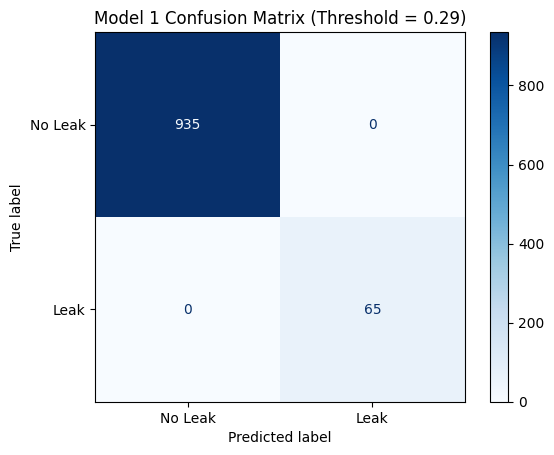


FINAL EVALUATION - MODEL 2 (ZONE LOCALIZATION)
Accuracy : 0.9730
Precision: 0.9741
Recall   : 0.9741
F1-Macro : 0.9741

Classification Report:
              precision    recall  f1-score   support

      Zone_1       0.93      0.94      0.93       205
      Zone_2       1.00      1.00      1.00       201
      Zone_3       1.00      1.00      1.00       190
      Zone_4       1.00      1.00      1.00       192
      Zone_5       0.94      0.93      0.94       212

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



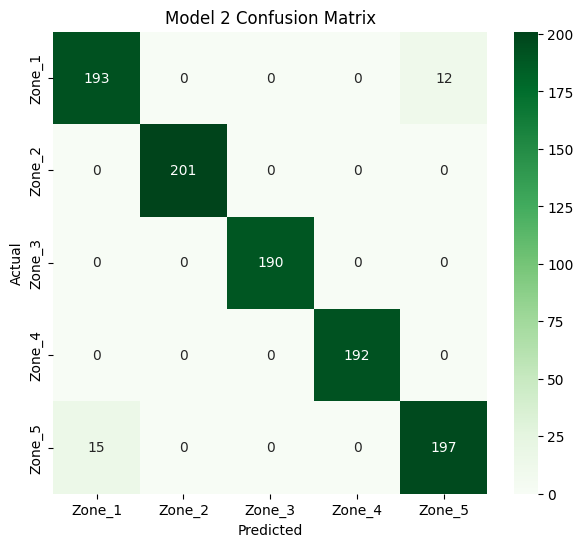


REAL TEST SAMPLE CHECK


,Pressure,Flow_Rate,Leakage_Flag,Zone,Status,Confidence,Zone_Predicted,Severity,Action
0,65.086084,69.914096,0,Zone_5,Normal,0.00%,N/A,N/A,Routine Monitoring
1,75.655240,97.714849,0,Zone_1,Normal,0.00%,N/A,N/A,Routine Monitoring
2,60.698021,68.361878,0,Zone_5,Normal,0.00%,N/A,N/A,Routine Monitoring
3,63.231855,86.185340,0,Zone_3,Normal,0.00%,N/A,N/A,Routine Monitoring
4,61.941076,88.168736,0,Zone_4,Normal,0.00%,N/A,N/A,Routine Monitoring
5,53.548802,84.337755,0,Zone_3,Normal,0.00%,N/A,N/A,Routine Monitoring
6,55.315039,95.371612,0,Zone_3,Normal,0.00%,N/A,N/A,Routine Monitoring
7,60.213116,98.460544,0,Zone_2,Normal,0.00%,N/A,N/A,Routine Monitoring
8,53.137209,68.064235,0,Zone_4,Normal,0.00%,N/A,N/A,Routine Monitoring
9,51.891425,108.468309,1,Zone_4,Leak,100.00%,Zone_4,Critical,Emergency Shutdown & Immediate Dispatch



SCENARIO TEST


,Pressure,Flow_Rate,Temperature,Vibration,Status,Confidence,Zone_Predicted,Severity,Action
0,30.0,120.0,105.0,4.5,Leak,92.00%,Zone_3,Critical,Emergency Shutdown & Immediate Dispatch
1,65.0,75.0,98.0,2.8,Normal,0.00%,N/A,N/A,Routine Monitoring
2,45.0,95.0,101.0,3.5,Leak,100.00%,Zone_5,Critical,Emergency Shutdown & Immediate Dispatch



SAVING FINAL ARTIFACTS
Saved:
- model1_final.pkl
- model2_final.pkl
- threshold.pkl
- label_encoder.pkl
- m1_features.pkl
- m2_features.pkl
- benchmark_model1.pkl
- benchmark_model2.pkl
- final_choices.pkl

RUNTIME TEST
{'Status': 'Leak', 'Confidence': '100.00%', 'Zone_Predicted': 'Zone_4', 'Severity': 'Critical', 'Action': 'Emergency Shutdown & Immediate Dispatch'}


In [40]:
# =========================================================
# FINAL CLOSING SCRIPT
# Option 2:
# Model 1 النهائي = Random Forest
# Model 2 النهائي = XGBoost
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# 0) FINAL MODEL REFERENCES
# =========================================================
# يفترض أن هذه المتغيرات موجودة مسبقًا في السشن:
# m1_pipeline  -> Random Forest pipeline for Model 1
# m2_pipeline  -> XGBoost pipeline for Model 2
# calibrated_threshold
# test_df
# df
# le
# m1_features
# m2_features

final_m1_model = m1_pipeline      # Random Forest
final_m2_model = m2_pipeline      # XGBoost
final_threshold = calibrated_threshold

print("=" * 90)
print("FINAL SYSTEM OVERVIEW")
print("=" * 90)
print("Model 1: Leak Detection")
print("Final Algorithm: Random Forest")
print("Task: Binary Classification")
print()
print("Model 2: Zone Localization")
print("Final Algorithm: XGBoost")
print("Task: Multiclass Classification (5 Zones)")
print()
print(f"Final Threshold for Model 1: {final_threshold:.4f}")

# =========================================================
# 1) FINAL BENCHMARKING TABLES
# =========================================================
print("\n" + "=" * 90)
print("FINAL BENCHMARKING RESULTS - MODEL 1")
print("=" * 90)

benchmark_m1 = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Decision Tree",
        "SVM",
        "Naive Bayes",
        "Logistic Regression",
        "KNN"
    ],
    "Recall (Mean)": [0.987644, 0.987644, 0.981421, 0.972163, 0.972115, 0.950481, 0.941106],
    "F1-Score (Mean)": [0.993750, 0.990720, 0.984447, 0.812166, 0.663471, 0.619426, 0.707654],
    "ROC-AUC (Mean)": [0.999990, 0.999964, 0.990294, 0.995440, 0.991575, 0.975807, 0.977267],
    "AUPRC (Mean)": [0.999860, 0.999500, 0.970431, 0.942260, 0.919000, 0.702540, 0.716720],
    "Recall (Std)": [0.011526, 0.011526, 0.011488, 0.011489, 0.005254, 0.015019, 0.011954]
}).sort_values(by=["Recall (Mean)", "F1-Score (Mean)"], ascending=False).reset_index(drop=True)

display(benchmark_m1)

print("\n" + "=" * 90)
print("FINAL BENCHMARKING RESULTS - MODEL 2")
print("=" * 90)

benchmark_m2 = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "KNN"
    ],
    "Accuracy (Mean)": [0.962933, 0.953702, 0.953558, 0.938125, 0.817308, 0.739760],
    "F1-Macro (Mean)": [0.963388, 0.954085, 0.953736, 0.938164, 0.817784, 0.739342]
}).sort_values(by=["Accuracy (Mean)", "F1-Macro (Mean)"], ascending=False).reset_index(drop=True)

display(benchmark_m2)

print("\n" + "=" * 90)
print("FINAL MODEL CHOICES")
print("=" * 90)

final_choices = pd.DataFrame({
    "Task": [
        "Model 1 - Leak Detection",
        "Model 2 - Zone Localization"
    ],
    "Selected Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Reason": [
        "Selected based on strongest overall Recall, F1, ROC-AUC, AUPRC, and stability in fair benchmarking.",
        "Although Random Forest had the best mean benchmark score, XGBoost was retained as the final model because it achieved stronger final test performance in the deployed pipeline."
    ]
})

display(final_choices)

# =========================================================
# 2) FINAL EVALUATION - MODEL 1
# =========================================================
print("\n" + "=" * 90)
print("FINAL EVALUATION - MODEL 1 (LEAK DETECTION)")
print("=" * 90)

y_test_m1_true = test_df["Leakage_Flag"]
y_test_m1_probs = final_m1_model.predict_proba(test_df[m1_features])[:, 1]
y_test_m1_pred = (y_test_m1_probs >= final_threshold).astype(int)

m1_acc = accuracy_score(y_test_m1_true, y_test_m1_pred)
m1_prec = precision_score(y_test_m1_true, y_test_m1_pred, zero_division=0)
m1_rec = recall_score(y_test_m1_true, y_test_m1_pred, zero_division=0)
m1_f1 = f1_score(y_test_m1_true, y_test_m1_pred, zero_division=0)
m1_roc = roc_auc_score(y_test_m1_true, y_test_m1_probs)

print(f"Accuracy : {m1_acc:.4f}")
print(f"Precision: {m1_prec:.4f}")
print(f"Recall   : {m1_rec:.4f}")
print(f"F1-Score : {m1_f1:.4f}")
print(f"ROC-AUC  : {m1_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_m1_true, y_test_m1_pred, target_names=["No Leak", "Leak"]))

cm1 = confusion_matrix(y_test_m1_true, y_test_m1_pred)
plt.figure(figsize=(6, 5))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["No Leak", "Leak"])
disp1.plot(cmap="Blues", values_format="d")
plt.title(f"Model 1 Confusion Matrix (Threshold = {final_threshold:.2f})")
plt.show()

# =========================================================
# 3) FINAL EVALUATION - MODEL 2
# =========================================================
print("\n" + "=" * 90)
print("FINAL EVALUATION - MODEL 2 (ZONE LOCALIZATION)")
print("=" * 90)

y_test_m2_true = le.transform(test_df["Zone"])
y_test_m2_pred = final_m2_model.predict(test_df[m2_features])

m2_acc = accuracy_score(y_test_m2_true, y_test_m2_pred)
m2_prec = precision_score(y_test_m2_true, y_test_m2_pred, average="macro", zero_division=0)
m2_rec = recall_score(y_test_m2_true, y_test_m2_pred, average="macro", zero_division=0)
m2_f1 = f1_score(y_test_m2_true, y_test_m2_pred, average="macro", zero_division=0)

print(f"Accuracy : {m2_acc:.4f}")
print(f"Precision: {m2_prec:.4f}")
print(f"Recall   : {m2_rec:.4f}")
print(f"F1-Macro : {m2_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_m2_true, y_test_m2_pred, target_names=le.classes_))

cm2 = confusion_matrix(y_test_m2_true, y_test_m2_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Model 2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# 4) FINAL INTEGRATED SYSTEM
# =========================================================
def final_system_predict(row):
    row_df = pd.DataFrame([row])

    # Model 1
    prob = final_m1_model.predict_proba(row_df[m1_features])[0][1]
    is_leak = prob >= final_threshold

    if not is_leak:
        return {
            "Status": "Normal",
            "Confidence": f"{prob:.2%}",
            "Zone_Predicted": "N/A",
            "Severity": "N/A",
            "Action": "Routine Monitoring"
        }

    # Model 2
    zone_idx = final_m2_model.predict(row_df[m2_features])[0]
    zone_name = le.inverse_transform([zone_idx])[0]

    # Rule-based severity
    pf = row_df["Pressure_Flow_Ratio"].values[0]
    if pf < 0.5:
        severity = "Critical"
        action = "Emergency Shutdown & Immediate Dispatch"
    elif pf < 0.8:
        severity = "High"
        action = "Dispatch Repair Team within 2 hours"
    else:
        severity = "Medium"
        action = "Schedule Maintenance within 24 hours"

    return {
        "Status": "Leak",
        "Confidence": f"{prob:.2%}",
        "Zone_Predicted": zone_name,
        "Severity": severity,
        "Action": action
    }

# =========================================================
# 5) REAL TEST SAMPLE CHECK
# =========================================================
print("\n" + "=" * 90)
print("REAL TEST SAMPLE CHECK")
print("=" * 90)

sample_real = test_df.sample(10, random_state=42).reset_index(drop=True)
sample_results = []

for _, row in sample_real.iterrows():
    sample_results.append(final_system_predict(row))

real_test_preview = pd.concat([
    sample_real[["Pressure", "Flow_Rate", "Leakage_Flag", "Zone"]],
    pd.DataFrame(sample_results)
], axis=1)

display(real_test_preview)

# =========================================================
# 6) SCENARIO TEST
# =========================================================
print("\n" + "=" * 90)
print("SCENARIO TEST")
print("=" * 90)

def generate_scenarios():
    scenarios = [
        {
            "Pressure": 30.0,
            "Flow_Rate": 120.0,
            "Temperature": 105.0,
            "Vibration": 4.5,
            "RPM": 2500,
            "Operational_Hours": 8000,
            "Latitude": 25.10,
            "Longitude": 55.20
        },
        {
            "Pressure": 65.0,
            "Flow_Rate": 75.0,
            "Temperature": 98.0,
            "Vibration": 2.8,
            "RPM": 1900,
            "Operational_Hours": 3000,
            "Latitude": 25.30,
            "Longitude": 55.40
        },
        {
            "Pressure": 45.0,
            "Flow_Rate": 95.0,
            "Temperature": 101.0,
            "Vibration": 3.5,
            "RPM": 2100,
            "Operational_Hours": 5000,
            "Latitude": 25.20,
            "Longitude": 55.30
        }
    ]
    scenario_df = pd.DataFrame(scenarios)
    scenario_df["Pressure_Flow_Ratio"] = scenario_df["Pressure"] / (scenario_df["Flow_Rate"] + 1e-6)
    scenario_df["Stress_Index"] = scenario_df["Vibration"] * scenario_df["RPM"]
    scenario_df["Usage_Intensity"] = scenario_df["Operational_Hours"] * scenario_df["RPM"]
    return scenario_df

scenario_df = generate_scenarios()
scenario_results = []

for _, row in scenario_df.iterrows():
    scenario_results.append(final_system_predict(row))

scenario_output = pd.concat([
    scenario_df[["Pressure", "Flow_Rate", "Temperature", "Vibration"]],
    pd.DataFrame(scenario_results)
], axis=1)

display(scenario_output)

# =========================================================
# 7) SAVE FINAL ARTIFACTS
# =========================================================
print("\n" + "=" * 90)
print("SAVING FINAL ARTIFACTS")
print("=" * 90)

joblib.dump(final_m1_model, "model1_final.pkl")
joblib.dump(final_m2_model, "model2_final.pkl")
joblib.dump(final_threshold, "threshold.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(m1_features, "m1_features.pkl")
joblib.dump(m2_features, "m2_features.pkl")
joblib.dump(benchmark_m1, "benchmark_model1.pkl")
joblib.dump(benchmark_m2, "benchmark_model2.pkl")
joblib.dump(final_choices, "final_choices.pkl")

print("Saved:")
print("- model1_final.pkl")
print("- model2_final.pkl")
print("- threshold.pkl")
print("- label_encoder.pkl")
print("- m1_features.pkl")
print("- m2_features.pkl")
print("- benchmark_model1.pkl")
print("- benchmark_model2.pkl")
print("- final_choices.pkl")

# =========================================================
# 8) RUNTIME FUNCTION
# =========================================================
def run_saved_style_prediction(input_dict):
    row_df = pd.DataFrame([input_dict])

    row_df["Pressure_Flow_Ratio"] = row_df["Pressure"] / (row_df["Flow_Rate"] + 1e-6)
    row_df["Stress_Index"] = row_df["Vibration"] * row_df["RPM"]
    row_df["Usage_Intensity"] = row_df["Operational_Hours"] * row_df["RPM"]

    prob = final_m1_model.predict_proba(row_df[m1_features])[0][1]
    leak_flag = prob >= final_threshold

    if not leak_flag:
        return {
            "Status": "Normal",
            "Confidence": f"{prob:.2%}",
            "Zone_Predicted": "N/A",
            "Severity": "N/A",
            "Action": "Routine Monitoring"
        }

    zone_idx = final_m2_model.predict(row_df[m2_features])[0]
    zone_name = le.inverse_transform([zone_idx])[0]

    pf = row_df["Pressure_Flow_Ratio"].values[0]
    if pf < 0.5:
        severity = "Critical"
        action = "Emergency Shutdown & Immediate Dispatch"
    elif pf < 0.8:
        severity = "High"
        action = "Dispatch Repair Team within 2 hours"
    else:
        severity = "Medium"
        action = "Schedule Maintenance within 24 hours"

    return {
        "Status": "Leak",
        "Confidence": f"{prob:.2%}",
        "Zone_Predicted": zone_name,
        "Severity": severity,
        "Action": action
    }

print("\n" + "=" * 90)
print("RUNTIME TEST")
print("=" * 90)

runtime_example = {
    "Pressure": 42.0,
    "Flow_Rate": 110.0,
    "Temperature": 102.0,
    "Vibration": 4.0,
    "RPM": 2300,
    "Operational_Hours": 6500,
    "Latitude": 25.15,
    "Longitude": 55.25
}

print(run_saved_style_prediction(runtime_example))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')